# DDSP Timbre Transfer (Local)

This notebook loads a local DDSP checkpoint and resynthesizes audio using extracted f0 and loudness features.

Requirements: `ddsp`, `librosa`, `soundfile`, `tensorflow`, and `gin`.

In [ ]:
import glob
import os
import time
import sys
from pathlib import Path

import gin
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import tensorflow.compat.v2 as tf

import ddsp
import ddsp.training

# Add src to path for local imports
PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from model_loading import find_model_dir, find_latest_checkpoint, load_pretrained_model
from feature_utils import (
    auto_adjust_features,
    compute_alignment,
    compute_features,
    load_dataset_stats,
    shift_f0,
    shift_loudness,
    trim_features,
)
from timbre_transfer import load_model, resynthesize
from utils import DEFAULT_SAMPLE_RATE
from visualize import plot_spectrograms, plot_features

In [2]:
# Parameters


input_audio_path = PROJECT_ROOT / "data/raw/voice/acapella/adele-rolling-in-the-deep-acapella.wav"
output_audio_dir = PROJECT_ROOT / "data/processed/voice/acapella_transfered"
sample_rate = DEFAULT_SAMPLE_RATE

# Pretrained model: Violin, Flute, Flute2, Trumpet, Tenor_Saxophone
model_name = "Violin"

# Optional: extract a segment (set to None to use entire file)
start_sec = 2*60 + 7  # e.g. 2 * 60 + 7 for 2:07
end_sec   = 2*60 + 25  # e.g. 2 * 60 + 25 for 2:25

pitch_shift = 0.0        # octaves
loudness_shift = 0.0     # dB
auto_adjust = True       # match pitch register + loudness to training data

threshold = 1.0          # note detection sensitivity
quiet = 20           # suppress silent regions (dB)
autotune = 0.0           # snap to nearest scale note (0 = off, 1 = full)

In [3]:
# Load audio
if not os.path.isfile(input_audio_path):
    raise FileNotFoundError(f"Audio file not found: {input_audio_path}")

full_audio, _ = librosa.load(str(input_audio_path), sr=sample_rate, mono=True)

# Optionally extract a segment
if start_sec is not None and end_sec is not None:
    start_sample = int(start_sec * sample_rate)
    end_sample   = int(end_sec * sample_rate)
    segment = full_audio[start_sample:end_sample]
    print(f"Loaded: {input_audio_path}")
    print(f"  Full length: {len(full_audio)/sample_rate:.1f}s")
    print(f"  Extracted segment: {start_sec}s – {end_sec}s ({len(segment)/sample_rate:.2f}s)")
else:
    segment = full_audio
    print(f"Loaded: {input_audio_path} ({len(segment)/sample_rate:.2f}s)")
def _format_timestamp(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    return f"{hours:02d}-{minutes:02d}-{secs:02d}" if hours else f"{minutes:02d}-{secs:02d}"

input_path = Path(input_audio_path)
if start_sec is not None and end_sec is not None:
    time_tag = f"_{_format_timestamp(start_sec)}_to_{_format_timestamp(end_sec)}"
else:
    time_tag = "_full"

segmented_audio_path = input_path.with_name(f"{input_path.stem}{time_tag}{input_path.suffix}")
sf.write(str(segmented_audio_path), segment, sample_rate)
print(f"Saved segmented audio to: {segmented_audio_path}")
from IPython.display import Audio, display
display(Audio(segment, rate=sample_rate))

Loaded: /home/namkhanh/Project/final_project/data/raw/voice/acapella/adele-rolling-in-the-deep-acapella.wav
  Full length: 222.4s
  Extracted segment: 127s – 145s (18.00s)
Saved segmented audio to: /home/namkhanh/Project/final_project/data/raw/voice/acapella/adele-rolling-in-the-deep-acapella_02-07_to_02-25.wav


In [4]:
# Compute features
audio = segment[np.newaxis, :]
audio_features = compute_features(audio)

# Optional: filter out f0 with low confidence (disabled for better pretrained model results)
# f0_confidence_threshold = 0.2
# low_confidence_mask = audio_features["f0_confidence"] < f0_confidence_threshold
# audio_features["f0_hz"][low_confidence_mask] = 0.0

# Build output path from input filename
input_stem = Path(input_audio_path).stem
output_audio = os.path.join(output_audio_dir, f"{input_stem}_TRANSFERED.wav")

audio_items = [
    {
        "input_path": str(input_audio_path),
        "output_path": output_audio,
        "audio": audio,
        "features": audio_features,
    }
]
print(f"Computed features for segment ({segment.shape[0]/sample_rate:.2f}s)")

2026-03-22 16:39:31.467365: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-22 16:39:31.490932: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-22 16:39:31.491016: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-22 16:39:31.491863: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

Computed features for segment (18.00s)


In [5]:
# Load pretrained model, compute alignment, apply conditioning, resynthesize
pretrained_dir = str(PROJECT_ROOT / "artifacts/ae")
result = load_pretrained_model(model_name, local_dir=pretrained_dir)
model_dir = result["model_dir"]
gin_file = result["gin_file"]
print(f"Loaded pretrained model: {model_name} from {model_dir}")

dataset_stats = load_dataset_stats(model_dir)
print(f"Dataset stats: {'loaded' if dataset_stats else 'not found (auto-adjust will be skipped)'}")

# Re-parse gin with audio dimensions and restore checkpoint
init_audio = audio_items[0]["audio"]
init_features = audio_items[0]["features"]
model, _ = load_model(model_dir, gin_file, init_audio, init_features)

# Get alignment from the gin config (now active after load_model)
time_steps, n_samples, hop_size = compute_alignment(init_audio)
print(f"Alignment: {time_steps} frames × {hop_size} hop = {n_samples} samples")

demo_audio = None
demo_audio_gen = None

for idx, item in enumerate(audio_items):
    audio = item["audio"]
    audio_features = {k: v.copy() if hasattr(v, 'copy') else v
                      for k, v in item["features"].items()}

    # 1. Trim features to exact model dimensions
    audio_features = trim_features(audio_features, time_steps, n_samples)

    # 2. Auto-adjust: match pitch register + loudness to training data
    if auto_adjust and dataset_stats is not None:
        audio_features = auto_adjust_features(
            audio_features,
            dataset_stats,
            threshold=threshold,
            quiet=quiet,
            autotune_amount=autotune,
        )
        print(f"  [{idx}] Applied auto-adjust (threshold={threshold}, quiet={quiet}dB, autotune={autotune})")
    else:
        print(f"  [{idx}] Auto-adjust skipped")

    # 3. Manual shifts
    audio_features = shift_loudness(audio_features, loudness_shift)
    audio_features = shift_f0(audio_features, pitch_shift)

    # 4. Resynthesize
    audio_gen = resynthesize(model, audio_features)

    os.makedirs(os.path.dirname(item["output_path"]), exist_ok=True)
    sf.write(item["output_path"], audio_gen, sample_rate)
    print(f"  [{idx}] Wrote {item['output_path']}")

    if idx == 0:
        demo_audio = audio
        demo_audio_gen = audio_gen

# Keep the first sample for display
audio = demo_audio
audio_gen = demo_audio_gen

2026-03-22 16:39:48.700351: W tensorflow/core/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata".


KeyboardInterrupt: 

In [ ]:
# Listen back (first sample only)
from IPython.display import Audio, display
display(Audio(audio[0], rate=sample_rate))
display(Audio(audio_gen, rate=sample_rate))

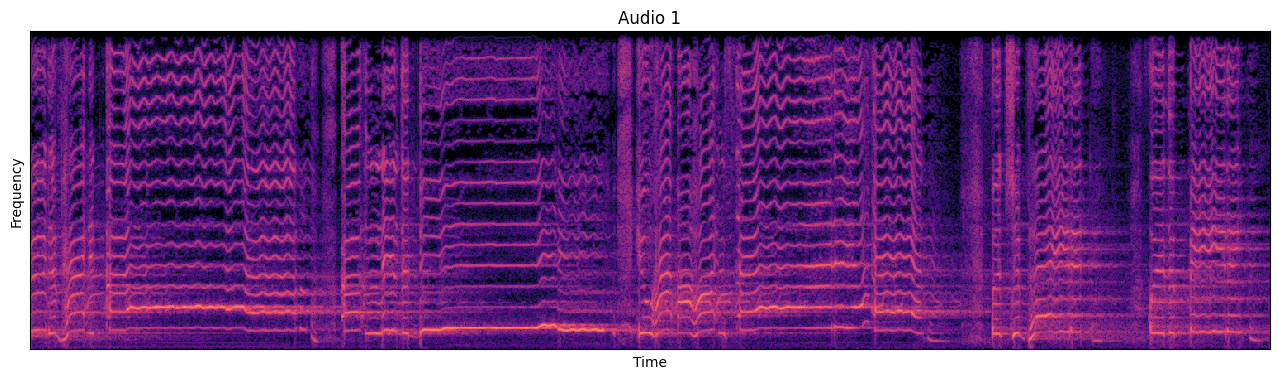

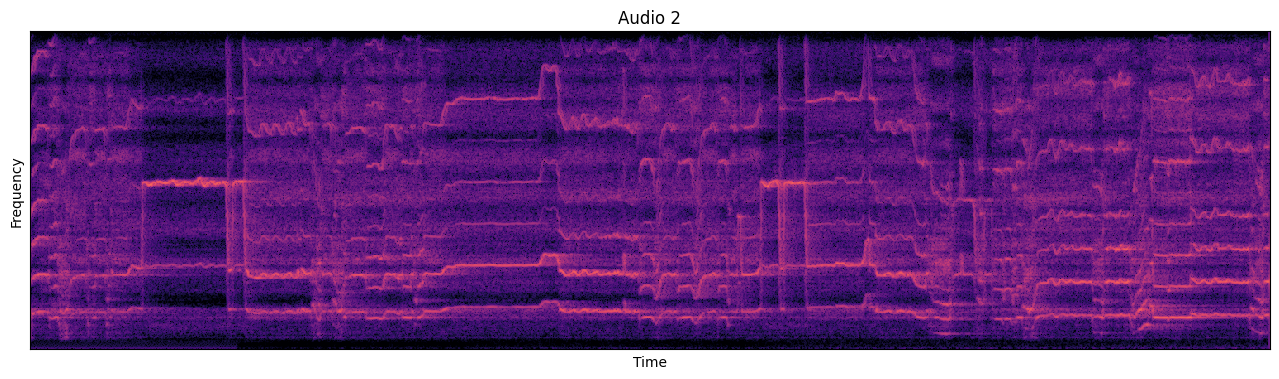

In [ ]:
# Spectrograms (first sample only)
plot_spectrograms([audio[0], audio_gen], sample_rate)

Original audio features:


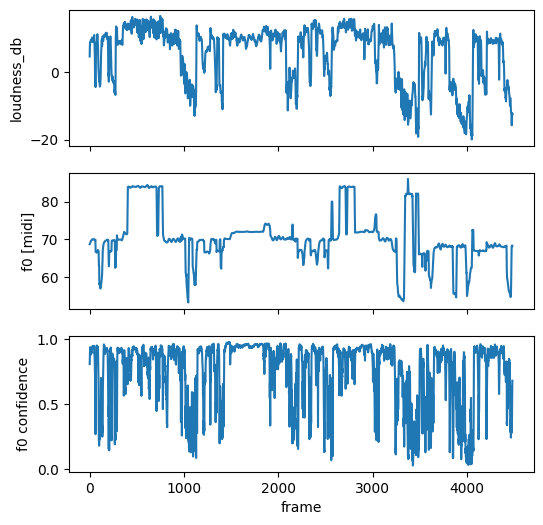

Generated audio features:


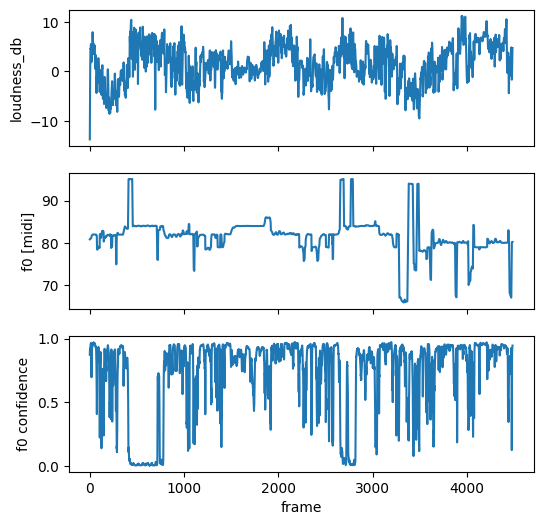

In [ ]:
# Audio features (original input)
print("Original audio features:")
plot_features(audio_items[0]["features"])

# Recompute features on the generated audio for comparison
audio_gen_features = compute_features(audio_gen[np.newaxis, :])
print("Generated audio features:")
plot_features(audio_gen_features)